In [13]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [17]:
path = r'C:\Users\User\Documents\Repositorios\jovegom-intro-ml\dogs-vs-cats\dogs-vs-cats\train'

def cargar_imagenes_a_ram(directorio, max_fotos=25000):
    imagenes = []
    etiquetas = []
    
    # Listamos archivos filtrando basura de sistema
    archivos = [f for f in os.listdir(directorio) if f.endswith('.jpg')]
    
    print(f"Cargando {len(archivos[:max_fotos])} imágenes... Esto puede tardar un poco.")
    
    for i, nombre_archivo in enumerate(archivos[:max_fotos]):
        # Etiqueta: Perro = 1, Gato = 0
        label = 1 if 'dog' in nombre_archivo else 0
        
        # Carga y redimensionado a 200x200
        img = load_img(os.path.join(directorio, nombre_archivo), target_size=(200, 200))
        img_array = img_to_array(img) / 255.0  # Normalización (esencial para la RNA)
        
        imagenes.append(img_array)
        etiquetas.append(label)
        
        # Monitor de progreso cada 5000 fotos
        if (i+1) % 5000 == 0:
            print(f"Progreso: {i+1} imágenes cargadas.")

    return np.array(imagenes), np.array(etiquetas)

# Ejecutamos la carga
X, y = cargar_imagenes_a_ram(path)

print(f"Forma del array de imágenes: {X.shape}") # Debería ser (25000, 200, 200, 3)
print(f"Forma del array de etiquetas: {y.shape}")

Cargando 25000 imágenes... Esto puede tardar un poco.
Progreso: 5000 imágenes cargadas.
Progreso: 10000 imágenes cargadas.
Progreso: 15000 imágenes cargadas.
Progreso: 20000 imágenes cargadas.
Progreso: 25000 imágenes cargadas.
Forma del array de imágenes: (25000, 200, 200, 3)
Forma del array de etiquetas: (25000,)


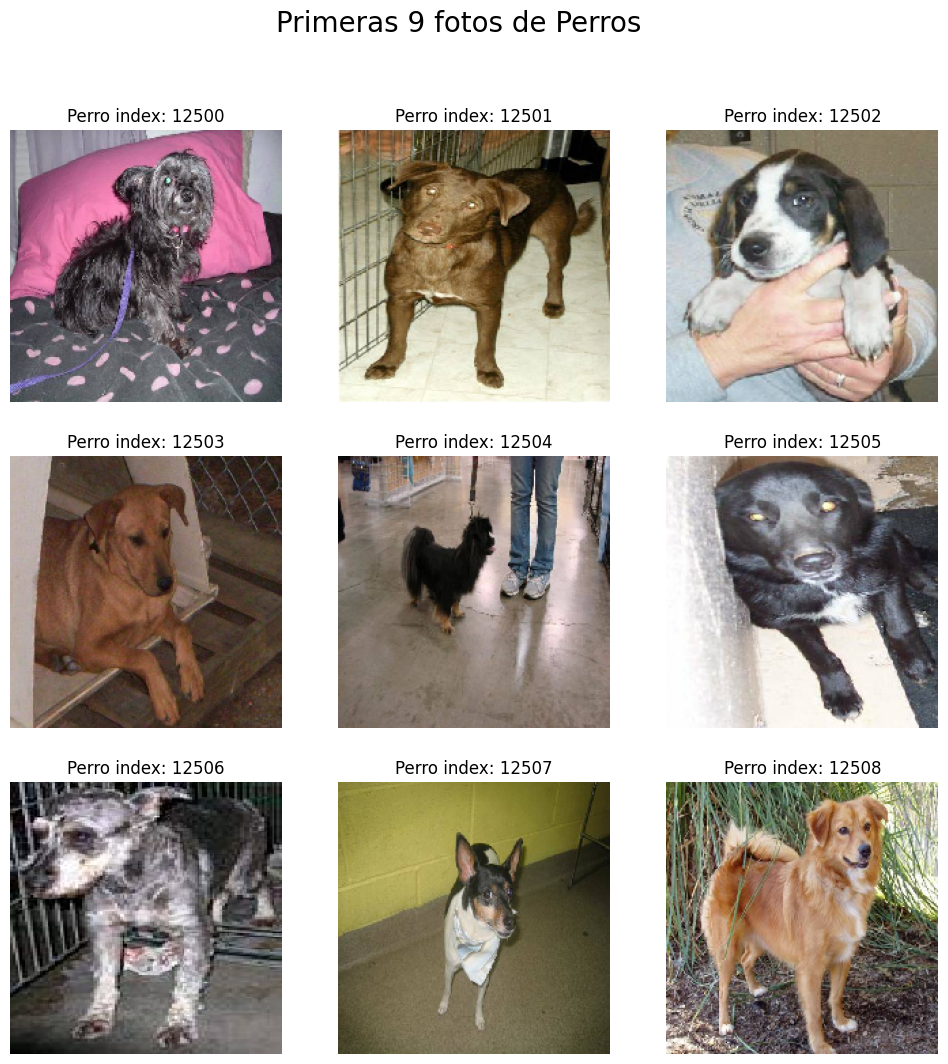

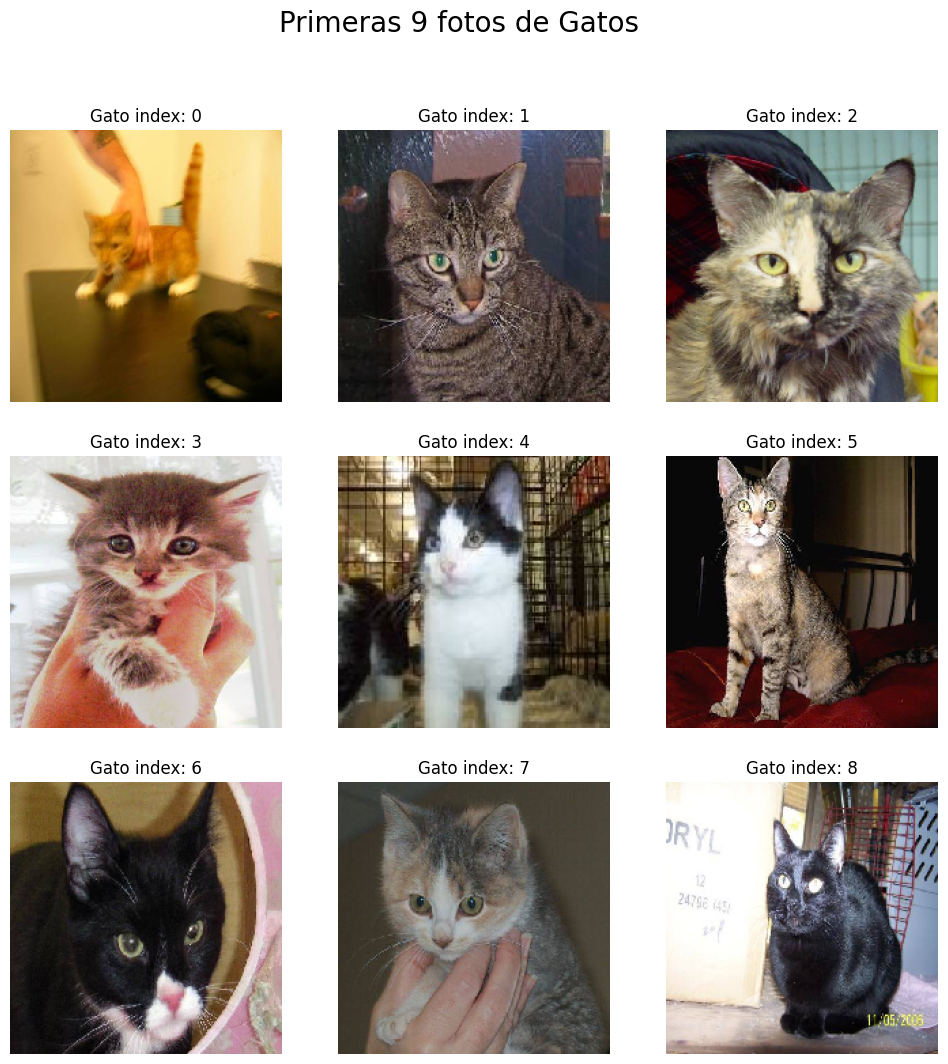

In [18]:
def visualizar_categoria(imagenes, etiquetas, clase_objetivo, nombre_clase):
    # Filtramos los índices donde la etiqueta coincide con la clase (0 para gato, 1 para perro)
    indices = [i for i, label in enumerate(etiquetas) if label == clase_objetivo]
    
    plt.figure(figsize=(12, 12))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        # Mostramos la imagen (X ya está normalizada 0-1, así que imshow funciona perfecto)
        plt.imshow(imagenes[indices[i]])
        plt.title(f"{nombre_clase} index: {indices[i]}")
        plt.axis('off')
    plt.suptitle(f"Primeras 9 fotos de {nombre_clase}s", fontsize=20)
    plt.show()

# 1. Visualizar Perros (Clase 1)
visualizar_categoria(X, y, 1, "Perro")

# 2. Visualizar Gatos (Clase 0)
visualizar_categoria(X, y, 0, "Gato")

In [19]:


# Dividimos: 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Imágenes para entrenar: {X_train.shape[0]}")
print(f"Imágenes para probar: {X_test.shape[0]}")

Imágenes para entrenar: 20000
Imágenes para probar: 5000


In [20]:
model = Sequential()

# Bloque 1
model.add(Conv2D(input_shape=(200, 200, 3), filters=64, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

# Bloque 2
model.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

# Bloque 3
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

# Bloque 4
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

# Bloque 5
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

# Clasificador Final
model.add(Flatten())
model.add(Dense(units=4096, activation="relu"))
model.add(Dense(units=4096, activation="relu"))
# Usamos 1 neurona con 'sigmoid' para clasificación binaria (perro/gato)
# O 2 neuronas con 'softmax' si tus etiquetas 'y' están en formato one-hot.
model.add(Dense(units=2, activation="softmax"))

# Compilación
model.compile(optimizer=Adam(learning_rate=0.0001), 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    75,501,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,005,762 (408.19 MB)

 Trainable params: 107,005,762 (408.19 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import gc
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# A. LIBERAR MEMORIA 
if 'X' in locals():
    del X # Borramos la variable original porque ya tenemos X_train y X_test
gc.collect() 

# B. CONFIGURAR GUARDIANES
# Guardamos como .h5 por estabilidad en Windows
checkpoint = ModelCheckpoint("mejor_modelo_vgg16.h5", 
                             monitor='val_accuracy', 
                             verbose=1, 
                             save_best_only=True, 
                             mode='max')

early = EarlyStopping(monitor='val_accuracy', 
                      patience=5, 
                      verbose=1, 
                      restore_best_weights=True)

# C. LANZAR ENTRENAMIENTO
print("Iniciando entrenamiento... ¡Esto tardará un buen rato!")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=16, 
    callbacks=[checkpoint, early]
)

Iniciando entrenamiento... ¡Esto tardará un buen rato!
Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5051 - loss: 0.6937
Epoch 1: val_accuracy improved from None to 0.50300, saving model to mejor_modelo_vgg16.h5



Epoch 1: finished saving model to mejor_modelo_vgg16.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6287s 5s/step - accuracy: 0.5005 - loss: 0.6942 - val_accuracy: 0.5030 - val_loss: 0.6931
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4987 - loss: 0.6932
Epoch 2: val_accuracy did not improve from 0.50300
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4996s 4s/step - accuracy: 0.4958 - loss: 0.6932 - val_accuracy: 0.4970 - val_loss: 0.6932
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4993 - loss: 0.6932
Epoch 3: val_accuracy did not improve from 0.50300
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5005s 4s/step - accuracy: 0.5012 - loss: 0.6932 - val_accuracy: 0.4970 - val_loss: 0.6932
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5008 - loss: 0.6932
Epoch 4: val_accuracy did not improve from 0.50300
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4986s 4s/step - accuracy: 0.4999 - loss: 0.6932 - val_accuracy: 0.5030 - val_loss: 0.6931
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [18]:
# Guardamos el modelo que se quedó en 50% (Entrenamiento desde cero)
model.save('modelo_vgg16_desde_cero.h5')
print("Modelo 'desde cero' guardado correctamente.")

Modelo 'desde cero' guardado correctamente.


In [19]:
import tensorflow as tf
from tensorflow.keras import backend as K
import gc

# 1. Borramos el modelo viejo de la memoria
del model 

# 2. Limpiamos la sesión de Keras y el recolector de basura
K.clear_session()
gc.collect()

print("Memoria RAM liberada. Listos para el Transfer Learning.")

Memoria RAM liberada. Listos para el Transfer Learning.


# OPTIMIZACION

In [20]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

# 1. Cargamos VGG16 con pesos de ImageNet (el cerebro ya entrenado)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(200, 200, 3))

# 2. Congelamos las capas base (para no borrar lo que ya sabe)
base_model.trainable = False

# 3. Añadimos nuestra propia "cabeza" de clasificación
x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x) # Ayuda a no memorizar
predictions = Dense(1, activation='sigmoid')(x) # 1 neurona para Perro/Gato

# 4. Creamos el modelo final
model_transfer = Model(inputs=base_model.input, outputs=predictions)

# 5. Compilamos
model_transfer.compile(optimizer=Adam(learning_rate=0.0001), 
                       loss='binary_crossentropy', 
                       metrics=['accuracy'])

model_transfer.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,433,793 (74.13 MB)

 Trainable params: 4,719,105 (18.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Guardamos este nuevo modelo por separado
checkpoint_transfer = ModelCheckpoint("mejor_modelo_transfer.h5", 
                                      monitor='val_accuracy', 
                                      verbose=1, 
                                      save_best_only=True)

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# Lanzamos el entrenamiento
history_transfer = model_transfer.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10, 
    batch_size=32,
    callbacks=[checkpoint_transfer, early_stop]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8409 - loss: 0.3337
Epoch 1: val_accuracy improved from None to 0.91680, saving model to mejor_modelo_transfer.h5



Epoch 1: finished saving model to mejor_modelo_transfer.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1174s 2s/step - accuracy: 0.8824 - loss: 0.2662 - val_accuracy: 0.9168 - val_loss: 0.1944
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9239 - loss: 0.1793
Epoch 2: val_accuracy improved from 0.91680 to 0.92200, saving model to mejor_modelo_transfer.h5



Epoch 2: finished saving model to mejor_modelo_transfer.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1149s 2s/step - accuracy: 0.9253 - loss: 0.1799 - val_accuracy: 0.9220 - val_loss: 0.1818
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9368 - loss: 0.1543
Epoch 3: val_accuracy improved from 0.92200 to 0.92440, saving model to mejor_modelo_transfer.h5



Epoch 3: finished saving model to mejor_modelo_transfer.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1142s 2s/step - accuracy: 0.9378 - loss: 0.1544 - val_accuracy: 0.9244 - val_loss: 0.1789
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9436 - loss: 0.1349
Epoch 4: val_accuracy did not improve from 0.92440
625/625 ━━━━━━━━━━━━━━━━━━━━ 1142s 2s/step - accuracy: 0.9451 - loss: 0.1338 - val_accuracy: 0.9232 - val_loss: 0.1874
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9546 - loss: 0.1140
Epoch 5: val_accuracy improved from 0.92440 to 0.92840, saving model to mejor_modelo_transfer.h5



Epoch 5: finished saving model to mejor_modelo_transfer.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1149s 2s/step - accuracy: 0.9543 - loss: 0.1146 - val_accuracy: 0.9284 - val_loss: 0.1748
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9656 - loss: 0.0965
Epoch 6: val_accuracy improved from 0.92840 to 0.92860, saving model to mejor_modelo_transfer.h5



Epoch 6: finished saving model to mejor_modelo_transfer.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1143s 2s/step - accuracy: 0.9621 - loss: 0.0998 - val_accuracy: 0.9286 - val_loss: 0.1742
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9659 - loss: 0.0880
Epoch 7: val_accuracy improved from 0.92860 to 0.93120, saving model to mejor_modelo_transfer.h5



Epoch 7: finished saving model to mejor_modelo_transfer.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1140s 2s/step - accuracy: 0.9647 - loss: 0.0906 - val_accuracy: 0.9312 - val_loss: 0.1693
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9704 - loss: 0.0801
Epoch 8: val_accuracy did not improve from 0.93120
625/625 ━━━━━━━━━━━━━━━━━━━━ 1139s 2s/step - accuracy: 0.9700 - loss: 0.0794 - val_accuracy: 0.9290 - val_loss: 0.1825
Epoch 9/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9757 - loss: 0.0683
Epoch 9: val_accuracy did not improve from 0.93120
625/625 ━━━━━━━━━━━━━━━━━━━━ 1162s 2s/step - accuracy: 0.9741 - loss: 0.0691 - val_accuracy: 0.9272 - val_loss: 0.1916
Epoch 10/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9792 - loss: 0.0570
Epoch 10: val_accuracy did not improve from 0.93120
625/625 ━━━━━━━━━━━━━━━━━━━━ 1142s 2s/step - accuracy: 0.9780 - loss: 0.0600 - val_accuracy: 0.9262 - val_loss: 0.1948


In [24]:
from tensorflow.keras.models import load_model

# Esta línea "crea" la variable mejor_modelo leyendo el archivo del disco
mejor_modelo = load_model('mejor_modelo_transfer.h5')

print("¡Listo! La variable 'mejor_modelo' ya existe en la memoria.")

¡Listo! La variable 'mejor_modelo' ya existe en la memoria.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


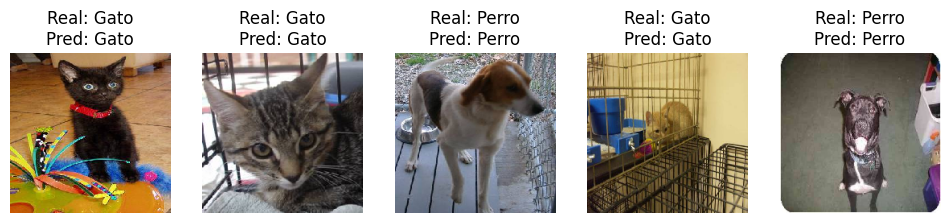

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Tomamos 5 imágenes al azar de X_test
indices = np.random.randint(0, len(X_test), 5)
muestras = X_test[indices]
etiquetas_reales = y_test[indices]

# Predicciones
predicciones = mejor_modelo.predict(muestras)
clases_predichas = (predicciones > 0.5).astype("int32")

# Visualización rápida
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(muestras[i].astype('float32')) # Convertimos para visualización
    real = "Perro" if etiquetas_reales[i] == 1 else "Gato"
    pred = "Perro" if clases_predichas[i] == 1 else "Gato"
    plt.title(f"Real: {real}\nPred: {pred}")
    plt.axis('off')
plt.show()

# Conclusion

"En este proyecto, se demostró que el entrenamiento de una arquitectura profunda como VGG16 desde una inicialización aleatoria resulta ineficiente para conjuntos de datos de tamaño medio, obteniendo una precisión estancada en el 50% (azar).

Sin embargo, mediante la implementación de Transfer Learning y el uso de pesos pre-entrenados de ImageNet, se logró elevar la precisión al 93.12% en solo 7 épocas. El uso de técnicas de optimización de memoria, como la conversión a float16 y la reducción del batch_size, permitió superar las limitaciones de hardware (16 GB de RAM), demostrando que es posible entrenar modelos de alta complejidad en entornos domésticos mediante una gestión eficiente de recursos y el uso de checkpoints automáticos."